In [15]:
from sklearn.datasets import make_classification
from matplotlib import pyplot
from pandas import DataFrame
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

In [16]:
# Generate 2-Class Classification Dataset
#X, y = make_classification(n_samples=200, n_classes=2, n_features=25)

X, y = make_classification(n_samples=500,
    n_features=20, n_redundant=2, n_informative=15, n_clusters_per_class=2, n_classes=2
)

X = pd.DataFrame(X)

In [17]:
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (500, 20)
y shape: (500,)


<AxesSubplot:xlabel='component-one', ylabel='component-two'>

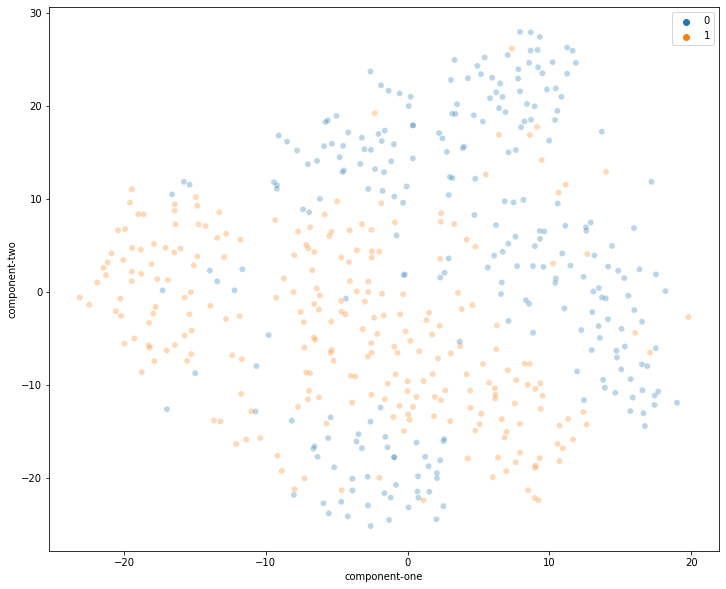

In [18]:
tsne_data = X.copy()

# define t-sne model
tsne = TSNE(init='random',
            learning_rate=200.0,
            n_components=2,
            random_state=0)

tsne_results = tsne.fit_transform(tsne_data)

tsne_data['component-one'] = tsne_results[:,0]
tsne_data['component-two'] = tsne_results[:,1]

plt.figure(figsize=(12,10))
sns.scatterplot(x=tsne_data["component-one"], 
                y=tsne_data["component-two"],
                hue=y.ravel(),
                palette=sns.color_palette("tab10", n_colors=2),
                legend="full",
                alpha=0.3)

In [19]:
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.svm import SVC
from simulated_annealing_module import simulated_annealing as sa
from sklearn.model_selection import GridSearchCV

In [20]:
rng = np.random.RandomState(0)

Iteration 0
grid search: 0.7726135305280427
Halving: 0.16222904932582352
Annealing: 0.16913580246913582
Iteration 1
grid search: 0.7937046586110682
Halving: 0.748810185243942
Annealing: 0.16913580246913582
Iteration 2
grid search: 0.8158086264517648
Halving: 0.7942066705360343
Annealing: 0.8155004732980832
Iteration 3
grid search: 0.7973660531055122
Halving: 0.7535128487874639
Annealing: 0.2419261637239165
Iteration 4
grid search: 0.7599242594676974
Halving: 0.6948519310776394
Annealing: 0.7599242594676974
Iteration 5
grid search: 0.6996900529846267
Halving: 0.6466209233953025
Annealing: 0.6747429242734745
Iteration 6
grid search: 0.7446561509658011
Halving: 0.16490299823633156
Annealing: 0.7446561509658011
Iteration 7
grid search: 0.6963448724076665
Halving: 0.6272255399390124
Annealing: 0.6673059294639841
Iteration 8
grid search: 0.7790698126238196
Halving: 0.7245284366252108
Annealing: 0.21957322254744593
Iteration 9
grid search: 0.7739973291690686
Halving: 0.15925925925925924
Annea

grid search: 0.8092341149469563
Halving: 0.7184341317790248
Annealing: 0.16913580246913582
Iteration 81
grid search: 0.7436712046656959
Halving: 0.6009298532691414
Annealing: 0.7245118380103213
Iteration 82
grid search: 0.6957475694090025
Halving: 0.1621721567958127
Annealing: 0.670479739172352
Iteration 83
grid search: 0.7632020392448106
Halving: 0.6526854249595241
Annealing: 0.7577300062533977
Iteration 84
grid search: 0.7226820279796481
Halving: 0.15127070864775782
Annealing: 0.7226820279796481
Iteration 85
grid search: 0.7735923908209622
Halving: 0.17760157545605307
Annealing: 0.23271604938271606
Iteration 86
grid search: 0.8227336055103125
Halving: 0.6861436505244556
Annealing: 0.7847556609745774
Iteration 87
grid search: 0.7903902343810438
Halving: 0.6200887035638066
Annealing: 0.17100846164516578
Iteration 88
grid search: 0.8635956931070199
Halving: 0.7561527164554919
Annealing: 0.858580743739911
Iteration 89
grid search: 0.6356192090064545
Halving: 0.17233723853849034
Annealing

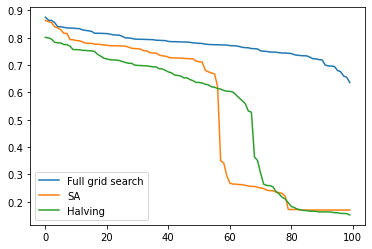

In [21]:
#clf = SVC(kernel='rbf', random_state=rng)

# clf= sa.Simulated_annealing(
#     baseClassifier=SVC(kernel='rbf'),
#     parameters_grid = {'C': [1e-3, 0.01, 0.1, 1, 2, 3, 4, 5,6,7,8,10,12,15,20,30],
#    'gamma': [8,7,6,5,4,3, 2,1, 0.5, 0.1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7]},
#     # The initial trial solution for starting the algorithm.
#     # Note that these are the coordinates in the grid of hyper parameters.
#     # In this example it would be C = 0.1 and gamma = 1
#     initial_trial_solution=[1,1],
#     # Cross validation folds. In each iteration the algorithm performs a cross validated fit.
#     cv= 5,
#     max_iterations = 100,
#     # Initial temperature. The higher the temperature, the greatest the 'turbulence' in the trial solutions hyper params.
#     initTemp = 3000,
#     # Initial value for the disturbance factor. This controls the amount of the flunctuations of the hyper params on a given temperature.
#     init_c = 5,
#     # This factor is the temperature reduction factor. It controls the rate of cooling. Max is 1 (no temperature reduction at all)
#     a = 0.97)

param_dist = {'C': [1e-3, 0.01, 0.1, 1, 2, 3, 4, 5,6,7,8,
                    10,12,15,20,30,40,50,60,70,80,90,100],
              'gamma': [16,15,14,13,12,10,9,8,7,6,5,4,3,
                        2,1,0.5,0.1,1e-2,1e-3,1e-4,1e-5,1e-6,1e-7],
             }

halving_scores = []
annealing_scores = []
grid_search_scores = []

for i in range(100):
    
    X, y = make_classification(n_samples=200, n_features=20,
                               n_informative=15, n_clusters_per_class=2, n_classes=3)
    
    print(f'Iteration {i}')
    clf = SVC(kernel='rbf', 
              random_state=rng
             )
    hrs = HalvingRandomSearchCV(estimator=clf,
                                param_distributions=param_dist,
                                factor=2,
                                random_state=rng,
                                scoring='f1_macro',
                                cv=3
                               )
    hrs.fit(X,y)
    h_score = hrs.best_score_
    
    clf = SVC(kernel='rbf',
              random_state=rng
             )
    sas = sa.Simulated_annealing(baseClassifier=clf,
                                 parameters_grid=param_dist,
                                 initial_trial_solution=[1,1],
                                 cv= 3,
                                 max_iterations = 100,
                                 initTemp = 3000,
                                 init_c = 5,
                                 a = 0.97)
    
    gs = GridSearchCV(SVC(), param_dist, scoring=['f1_macro'], refit='f1_macro', verbose=0, cv=3, n_jobs=-1)
    gs.fit(X, y)
    print(f'grid search: {gs.best_score_}')
    grid_search_scores.append(gs.best_score_)
    

    
    results = sas.fit(X,y)
    a_score = sas.get_params()['cost']
    
    print(f'Halving: {h_score}')
    halving_scores.append(h_score)
    
    print(f'Annealing: {a_score}')
    annealing_scores.append(a_score)
    
    
    
import matplotlib.pyplot as plt
import numpy as np


x_axis = list(range(0, len(grid_search_scores)))
grid_search_scores.sort(reverse=True)
annealing_scores.sort(reverse=True)
halving_scores.sort(reverse=True)

plt.plot(x_axis, grid_search_scores, label= "Full grid search")
plt.plot(x_axis, annealing_scores, label = "SA")
plt.plot(x_axis, halving_scores, label = "Halving")
plt.legend()
plt.show()
